In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# What data is available?

In [ ]:
# Load the dataframes

HOME_PATH = "~/Downloads/" # change this to your own path


## Preprocess the metadata
1. Extract the 73 `dataids` that appear in the provided 1-minute dataframes
2. Remove empty columns
3. Remove irrelevant columns
4. Compute the availability of each feature across the 73 homes and sort in descending order
5. Save the preprocessed metadata in `metadata_df`
6. Save the feature descriptions and availability percentage in `metadata_df`

In [122]:
# A hand-chosen list of columns that are not relevant to the analysis
IRRELEVANT_COLS = [
    "egauge_1min_min_time",	# If eGauge electricity data is present, this field will show the minimum timestamp of the available data.
	"egauge_1min_max_time",	# If eGauge electricity data is present, this field will show the maximum timestamp of the available data.
	"egauge_1min_data_availability",	# This field shows how much one minute data  is available for each home.
	"date_enrolled",	# The date on which this participant enrolled with Pecan Street.
	"egauge_1s_min_time",	# If eGauge electricity data is present in one second interval, this field will show the minimum timestamp of the available data.
	"egauge_1s_max_time",	# If eGauge electricity data is present in one second interval, this field will show the maximum timestamp of the available data.
	"egauge_1s_data_availability",	# This field shows how much one second data  is available for each home.
	"active_record",	# this field will show yes if this participant is currently enrolled with Pecan Street and will be blank otherwise.
	"date_withdrawn",	# The date on which this participant withdrew from participating with Pecan Street. If this field is blank, the participant is still enrolled.
	"gas_ert_min_time",	# If ERT gas data is present, this field will show the minimum timestamp of the available data.
	"gas_ert_max_time",	# If ERT gas data is present, this field will show the maximum timestamp of the available data.
	"gas_data_availability",	# This field shows how much gas data is available for each home.
	"indoor_temp_min_time",	# If indoor temperature sensor data is present, this field will show the minimum timestamp of the available data.
	"indoor_temp_max_time",	# If indoor temperature sensor data is present, this field will show the maximum timestamp of the available data.
	"indoor_temp_data_availability",	# This field shows how much indoor temperature data is available for each home.
	"water_ert_min_time",	# If ERT water data is present, this field will show the minimum timestamp of the available data.
	"water_ert_max_time",	# If ERT water data is present, this field will show the maximum timestamp of the available data.
	"water_data_availability",	# This field shows how much water data is available for each home.
    "audit_2011",	# This field will show 'yes' if a 2011 home energy audit is available for this house.
    "audit_2013_2014",	# This field will show 'yes' if a 2013 or later home energy audit is available for this house.
    "survey_2011",	# This field will show 'yes' if this participant completed the annual Pecan Street survey in 2011 and will be blank otherwise.
    "survey_2012",	# This field will show 'yes' if this participant completed the annual Pecan Street survey in 2012 and will be blank otherwise.
    "survey_2013",	# This field will show 'yes' if this participant completed the annual Pecan Street survey in 2013 and will be blank otherwise.
    "survey_2014",	# This field will show 'yes' if this participant completed the annual Pecan Street survey in 2014 and will be blank otherwise.
    "survey_2017",	# This field will show 'yes' if this participant completed the annual Pecan Street survey in 2017 and will be blank otherwise.
    "survey_2019",	# This field will show 'yes' if this participant completed the annual Pecan Street survey in 2019 and will be blank otherwise.
    "program_579",	# This field will show 'yes' if this participant is part of the 579 program and will be blank otherwise. The defining feature of the 579 program is that it includes participants in Texas outside the Austin area.
    "program_baseline",	# This field will show 'yes' if this participant is part of the Baseline program and will be blank otherwise. Baseline program participants were part of a behavioral study in which they were not allowed to see their data for the first year of the study (2011- 2012) and then were given a report with the details of their energy use. Data was collected for another year (2012-2013) for comparison, to see whether the participants reduced their energy use.
    "program_energy_internet_demo",	# This field will show 'yes' if this participant is part of the Energy Internet Demonstration program, which includes most Austin, Texas participants enrolled prior to 2014.
    "program_lg_appliance",	# This field will show 'yes' if this participant is part of the LG Appliance Trial and will be blank otherwise. These participants received new washers, dryers, and, in some cases, refrigerators as part of the trial. If the participant previously had a natural gas dryer monitored on their eGauge, it will have been replaced with an electric dryer at the time of the trial.
    "program_verizon",	# This field will show 'yes' if this participant is part of the Verizon program, which involves exclusively residents of four low-income apartment complexes in Austin, Texas. Most of these participants do not have home internet access, so each household was given a tablet to facilitate their ability to view their energy use on their eGauge monitoring system from home.
    "program_ccet_group",	# This field will show one of the following group labels if the participant was a member of the CCET Trial:CCET Control, CCET Portal Only, CCET Pricing Trial, CCET Text Message, CCET UT Text, The Control group was not affected by or informed of the study.Portal Only participants received access to the special portal displaying their experimental account balance (and thus knowledge of how the experimental pricing scheme would have affected them), but they did not receive a financial incentive as part of the study.ricing Trial participants received a financial incentive for shifting their electricity use away from peak hours on critical peak pricing days and shifting their electricity use toward wind-enhancement hours during the wind enhancement period of the study. They had access to a special portal that displayed their experimental account balance.Text Message participants received text messages asking them to reduce their energy consumption in general on peak days.UT Text participants received text messages asking them to restrict usage of specific appliances on peak days.
    "program_civita_group",	# This field will show one of the following group labels if the participant is a member of the Civita project:Civita Control, Civita Text Message, Text Message participants received text messages asking them to conserve energy in various ways. Control group participants were not affected.
    "program_shines",	# This field will show 'yes' if this participant is part of Shines program. For more information check out our blog here.
]

In [ ]:
# Read the applicable dataids and timespans

pre_metadata_df = pd.DataFrame()

for location in ["newyork", "austin", "california"]:
    print(f"\tReading dataids and timespans from {location}...")

    location_df = pd.read_csv(f"{HOME_PATH}/residential-power-forecasting/data/1minute_data_{location}/1minute_data_{location}.csv")
    
    # get the minimum and maximum localminute for each dataid
    location_df = location_df.groupby("dataid").agg(
        min_localminute=("localminute", "min"),
        max_localminute=("localminute", "max"),
    ).reset_index()

    location_df["location"] = location

    pre_metadata_df = pd.concat([pre_metadata_df, location_df])

    del location_df

	Reading dataids from newyork...
	Reading dataids from austin...
	Reading dataids from california...
    dataid         min_localminute         max_localminute location
0       27  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
1      142  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
2      387  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
3      558  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
4      914  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
5      950  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
6     1222  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
7     1240  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
8     1417  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
9     2096  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
10    2318  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
11    2358  2019-05-01 00:00:00-05  2019-10-31 23:59:00-05  newyork
12    3000  201

In [148]:
import os
PROCESSED_METADATA_PATH = os.path.expanduser(f"{HOME_PATH}/residential-power-forecasting/data/processed_metadata.csv")

if not os.path.exists(PROCESSED_METADATA_PATH):
    print("Processing metadata...")

    raw_metadata_df = pd.read_csv(f"{HOME_PATH}/residential-power-forecasting/data/metadata.csv")

    # Extract row 0, which provides string descriptions of each of the metadata columns
    description_row = raw_metadata_df.iloc[0]
    raw_metadata_df = raw_metadata_df.iloc[1:]

    # Convert columns to numeric
    raw_metadata_df = raw_metadata_df.apply(lambda col: pd.to_numeric(col, errors='coerce').fillna(col)).convert_dtypes()

    # Join the pre-metadata dataframe with the raw metadata dataframe using the dataid column
    metadata_df = pd.merge(pre_metadata_df, raw_metadata_df, on="dataid", how="left")

    # Drop the columns that are all NaN
    empty_metadata_cols = metadata_df.columns[metadata_df.isna().all()]
    print(f"empty_metadata_cols: {empty_metadata_cols}")
    metadata_df = metadata_df.drop(columns=empty_metadata_cols)
    description_row = description_row.drop(labels=empty_metadata_cols)

    # Drop irrelevant columns
    irrelevant_cols = list(set(IRRELEVANT_COLS) - set(empty_metadata_cols))
    print(f"irrelevant_cols: {irrelevant_cols}")
    metadata_df = metadata_df.drop(columns=irrelevant_cols)
    description_row = description_row.drop(labels=irrelevant_cols)

    # Compute availability (proportion non-NA) for all columns
    n_rows = len(metadata_df)
    availability = {
        col: metadata_df[col].notna().sum() / n_rows
        for col in metadata_df.columns
    }

    # Identify "time series" columns, identified by the description row containing "data present"
    time_series_cols = sorted(description_row[
        description_row.str.contains("data present", case=False, na=False)
    ].index.tolist(), key=lambda c: availability[c], reverse=True)

    # Sort each group by availability descending
    non_time_series_cols = sorted(
        [c for c in metadata_df.columns if c not in time_series_cols],
        key=lambda c: availability[c], reverse=True,
    )
    all_ordered_cols = non_time_series_cols + time_series_cols

    # Build description_df covering all columns
    description_df = pd.DataFrame(
        {
            "feature_name": all_ordered_cols,
            "description": [description_row.get(c, {
                "min_localminute": "The minimum localminute of the time series data present for this home",
                "max_localminute": "The maximum localminute of the time series data present for this home",
                "location": "Which of the 3 locations this home belongs to",
            }.get(c, "Missing description")) for c in all_ordered_cols],
            "availability": [availability[c] for c in all_ordered_cols],
            "type":  ["non-time-series"] * len(non_time_series_cols) + ["time-series"] * len(time_series_cols),
        },
    )

    # Reorder metadata_df:
    #   location | dataid | non-data-present cols (desc. availability) | data-present cols (desc. availability)
    metadata_df = metadata_df[all_ordered_cols]

    # Save the processed metadata
    metadata_df.to_csv(PROCESSED_METADATA_PATH, index=False)
    print(f"Metadata processed and saved to {PROCESSED_METADATA_PATH}")
    description_df.to_csv(PROCESSED_METADATA_PATH.replace(".csv", "_description.csv"), index=False)
    print(f"Description dataframe saved to {PROCESSED_METADATA_PATH.replace('.csv', '_description.csv')}")

else:
    print(f"File at {PROCESSED_METADATA_PATH} already exists. Loading from file")

Processing metadata...
empty_metadata_cols: Index(['air3', 'aquarium1', 'bedroom4', 'bedroom5', 'battery1', 'diningroom2',
       'garage2', 'heater3', 'icemaker1', 'lights_plugs5', 'lights_plugs6',
       'livingroom2', 'outsidelights_plugs2', 'pool1', 'pool2', 'poollight1',
       'poolpump1', 'shed1', 'program_579', 'program_verizon',
       'energy_storage_system', 'energy_storage_system_l1',
       'energy_storage_system_l2'],
      dtype='str')
irrelevant_cols: ['date_withdrawn', 'program_baseline', 'program_energy_internet_demo', 'indoor_temp_max_time', 'gas_data_availability', 'gas_ert_min_time', 'water_data_availability', 'egauge_1min_min_time', 'date_enrolled', 'program_lg_appliance', 'program_ccet_group', 'egauge_1min_max_time', 'water_ert_min_time', 'egauge_1s_min_time', 'program_civita_group', 'survey_2013', 'survey_2011', 'survey_2014', 'program_shines', 'survey_2019', 'indoor_temp_data_availability', 'indoor_temp_min_time', 'egauge_1s_data_availability', 'audit_2013_2014

In [151]:
display(description_df[description_df["type"] == "non-time-series"])
display(description_df[description_df["type"] == "time-series"])

,feature_name,description,availability,type
0,dataid,The unique identifier for the home. To be more...,1.000000,non-time-series
1,min_localminute,The minimum localminute of the time series dat...,1.000000,non-time-series
2,max_localminute,The maximum localminute of the time series dat...,1.000000,non-time-series
3,location,Which of the 3 locations this home belongs to,1.000000,non-time-series
4,building_type,This field will read Single-Family Home if thi...,1.000000,non-time-series
5,city,participant's city,1.000000,non-time-series
6,state,participant's state,1.000000,non-time-series
7,total_square_footage,The total square footage of the home.,0.917808,non-time-series
8,house_construction_year,The year in which this home was constructed.,0.794521,non-time-series
9,pv,This field will show 'yes' if this participant...,0.479452,non-time-series


,feature_name,description,availability,type
21,grid,eGauge data present measuring power drawn from...,0.876712,time-series
22,air1,Air compressor circuit eGauge data present.,0.780822,time-series
23,dishwasher1,Dishwasher circuit eGauge data present.,0.767123,time-series
24,furnace1,Furnace and air handler circuit eGauge data pr...,0.739726,time-series
25,kitchenapp1,First kitchen small appliance circuit eGauge d...,0.712329,time-series
26,refrigerator1,Refrigerator circuit eGauge data present.,0.712329,time-series
27,microwave1,Microwave circuit eGauge data present.,0.630137,time-series
28,clotheswasher1,Stand-alone clothes washing machine eGauge dat...,0.534247,time-series
29,disposal1,Kitchen sink garbage disposal circuit eGauge d...,0.534247,time-series
30,oven1,Oven circuit eGauge data present.,0.520548,time-series


# Explore the grid/EV data

In [213]:
# Which homes have car1 data?
car1_metadata_df = metadata_df[metadata_df["car1"] == "yes"]
display(car1_metadata_df)

car1_dataids = car1_metadata_df["dataid"].unique()

,dataid,min_localminute,max_localminute,location,building_type,city,state,total_square_footage,house_construction_year,pv,...,lights_plugs4,outsidelights_plugs1,oven2,refrigerator2,security1,sewerpump1,solar2,sumppump1,waterheater2,wellpump1
0,27,2019-05-01 00:00:00-05,2019-10-31 23:59:00-05,newyork,Single-Family Home 001 (Master),Brooktondale,New York,1575,1990,yes,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
12,3000,2019-05-01 00:00:00-05,2019-10-31 23:59:00-05,newyork,Single-Family Home 001 (Master),Ithaca,New York,2200,1954,yes,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,yes,<NA>,<NA>,<NA>
14,3517,2019-05-01 00:00:00-05,2019-10-31 23:59:00-05,newyork,Single-Family Home 001 (Master),Ithaca,New York,2200,1903,yes,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
19,5058,2019-05-01 00:00:00-05,2019-10-31 23:59:00-05,newyork,Single-Family Home 001 (Master),Ithaca,New York,1775,1987,yes,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
20,5587,2019-05-01 00:00:00-05,2019-10-31 23:59:00-05,newyork,Single-Family Home 001 (Master),Ithaca,New York,2325,1993,yes,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
21,5679,2019-05-01 00:00:00-05,2019-10-31 23:59:00-05,newyork,Single-Family Home 001 (Master),Ithaca,New York,1700,1952,yes,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
25,661,2018-01-01 00:00:00-06,2018-12-31 23:59:00-06,austin,Single-Family Home 001 (Master),Austin,Texas,1850,2007,yes,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
26,1642,2018-01-01 00:00:00-06,2018-12-31 23:59:00-06,austin,Single-Family Home 001 (Master),Austin,Texas,1725,2007,yes,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
27,2335,2018-01-01 00:00:00-06,2018-12-31 23:59:00-06,austin,Single-Family Home 001 (Master),Austin,Texas,2700,2008,yes,...,<NA>,<NA>,yes,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
28,2361,2018-01-01 00:00:00-06,2018-12-31 23:59:00-06,austin,Single-Family Home 001 (Master),Austin,Texas,3250,2009,yes,...,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


np.float64(3.432)

## Examine house metadata

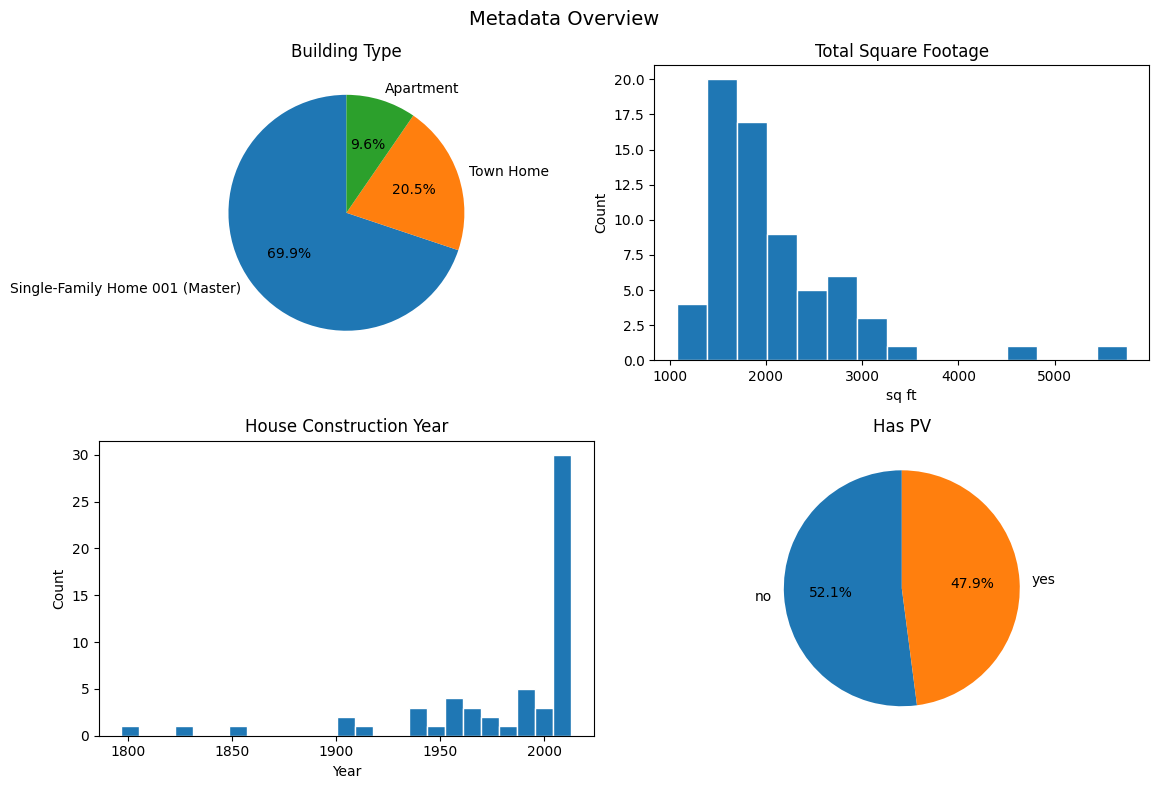

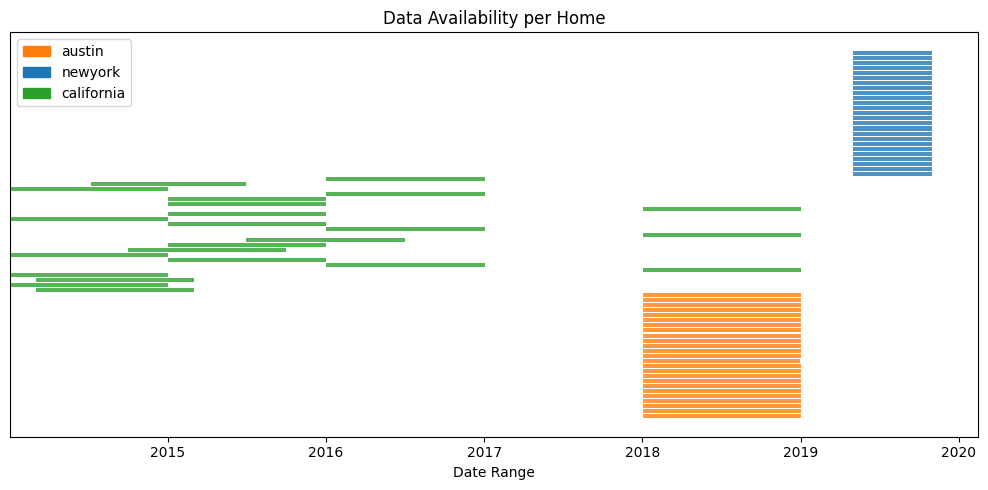

In [154]:
import matplotlib.patches as mpatches

# --- Plots 1–4: 2x2 grid ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Metadata Overview", fontsize=14)

# 1. Building type
bt = metadata_df['building_type'].value_counts()
axes[0, 0].pie(bt, labels=bt.index, autopct='%1.1f%%', startangle=90)
axes[0, 0].set_title("Building Type")

# 2. Square footage
axes[0, 1].hist(metadata_df['total_square_footage'].dropna(), bins=15, edgecolor='white')
axes[0, 1].set(title="Total Square Footage", xlabel="sq ft", ylabel="Count")

# 3. Construction year
axes[1, 0].hist(metadata_df['house_construction_year'].dropna(), bins=25, edgecolor='white')
axes[1, 0].set(title="House Construction Year", xlabel="Year", ylabel="Count")

# 4. PV presence
pv = metadata_df['pv'].fillna('no').value_counts()
axes[1, 1].pie(pv, labels=pv.index, autopct='%1.1f%%', startangle=90)
axes[1, 1].set_title("Has PV")

plt.tight_layout()
plt.show()

# --- Plot 5: data availability timeline per dataid ---
df = metadata_df[['dataid', 'min_localminute', 'max_localminute', 'location']].copy()
df['min_dt'] = pd.to_datetime(df['min_localminute'], utc=True)
df['max_dt'] = pd.to_datetime(df['max_localminute'], utc=True)
df = df.sort_values('location').reset_index(drop=True)

loc_colors = {'austin': 'tab:orange', 'newyork': 'tab:blue', 'california': 'tab:green'}

fig, ax = plt.subplots(figsize=(10, 5))
for i, row in df.iterrows():
    ax.barh(i, row['max_dt'] - row['min_dt'], left=row['min_dt'],
            color=loc_colors.get(row['location'], 'gray'), alpha=0.8)

ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.set_yticks([])
ax.set(title="Data Availability per Home", xlabel="Date Range")
ax.legend(handles=[mpatches.Patch(color=c, label=l) for l, c in loc_colors.items()])

plt.tight_layout()
plt.show()

# Examining Austin

In [ ]:
austin_df = pd.read_csv(f"{HOME_PATH}/residential-power-forecasting/data/1minute_data_austin/1minute_data_austin.csv")

# Remove any columns that are all NaN
austin_df = austin_df.dropna(axis=1, how='all')

In [195]:
austin_df["localminute"] = pd.to_datetime(austin_df["localminute"], utc=True)

In [ ]:
austin_time_series_cols = [col for col in time_series_cols if col in austin_df.columns] # ordered by availability across all 3 locations

## Comparing different homes

In [166]:
# For each col in austin_time_series_cols, report how many homes have data for that feature out of the total number
1 - austin_df[austin_time_series_cols].isna().sum()/len(austin_df)

grid                    0.994027
air1                    0.953874
dishwasher1             0.986250
furnace1                0.952040
kitchenapp1             0.788978
refrigerator1           0.911726
microwave1              0.871734
clotheswasher1          0.946036
disposal1               0.593307
oven1                   0.636423
kitchenapp2             0.634212
solar                   0.755741
drye1                   0.718434
livingroom1             0.348026
dryg1                   0.395433
lights_plugs1           0.474482
car1                    0.312818
bedroom1                0.438275
bathroom1               0.395058
lights_plugs2           0.354548
garage1                 0.114008
freezer1                0.076920
range1                  0.114590
kitchen1                0.158586
venthood1               0.277481
waterheater1            0.076980
bedroom2                0.159603
lights_plugs3           0.199925
air2                    0.078533
diningroom1             0.080148
utilityroo

## Variance across homes of time series averaged over time, for each time series

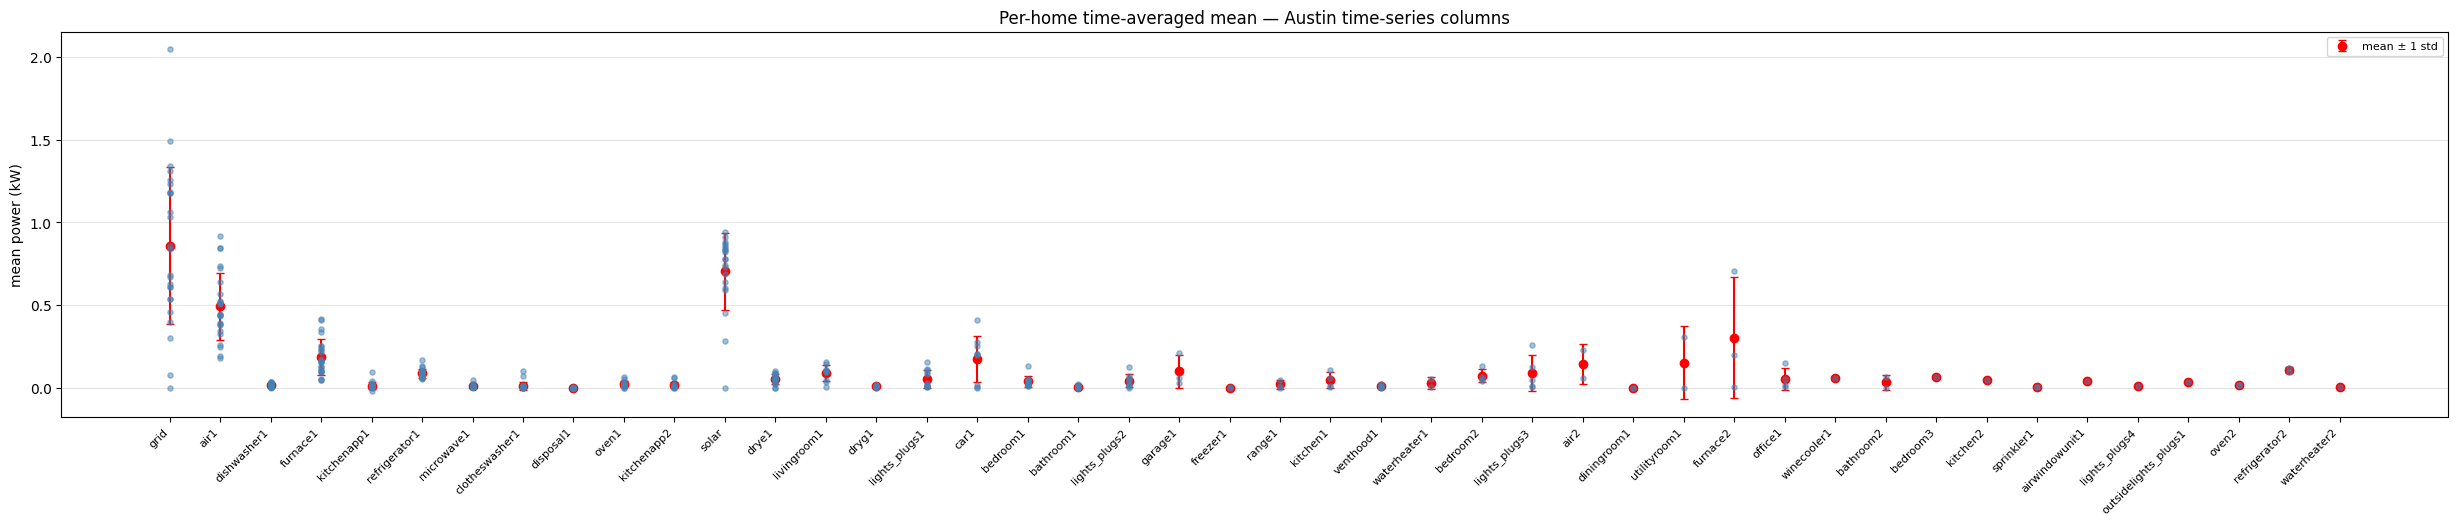

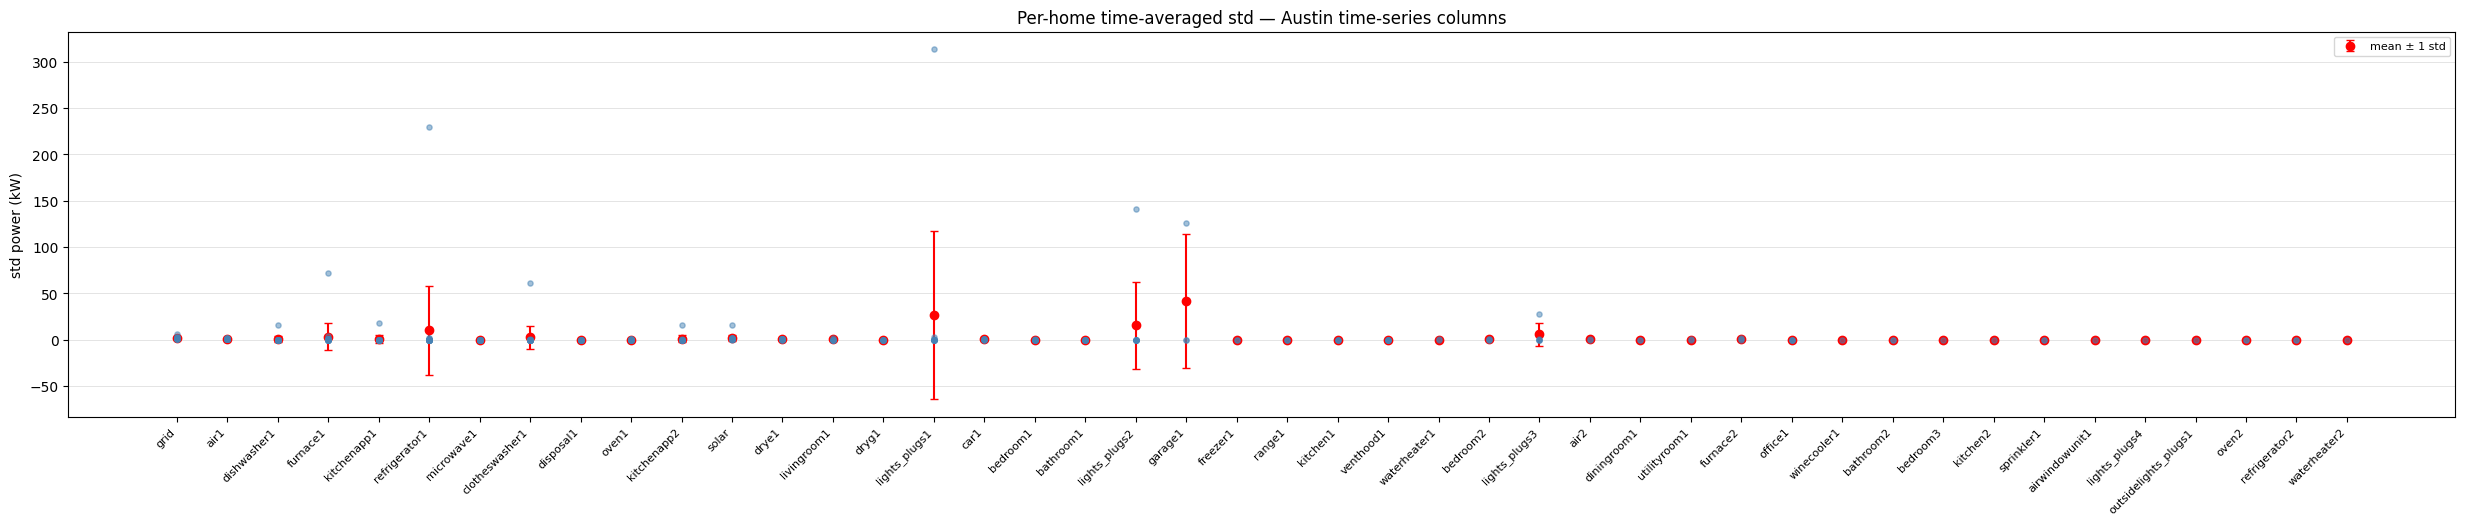

In [174]:
# --- Toggleable flags ---
SHOW_HOME_DOTS = True   # one dot per home at its time-averaged mean
SHOW_CI_BAND   = True   # band at mean ± 1 std of those home means

# Per-home time-average for each column
for metric in ["mean", "std"]:
    home_metrics = austin_df.groupby("dataid")[austin_time_series_cols].agg(metric)  # (n_homes, n_cols)

    metric_means = home_metrics.mean()
    metric_stds  = home_metrics.std()

    x = range(len(austin_time_series_cols))

    fig, ax = plt.subplots(figsize=(max(8, len(austin_time_series_cols) * 0.7), 5))

    if SHOW_CI_BAND:
        ax.errorbar(x, metric_means, yerr=metric_stds, fmt='o',
                color='red', capsize=3, label="mean ± 1 std")

    if SHOW_HOME_DOTS:
        for _, row in home_metrics.iterrows():
            ax.scatter(x, row.values, s=14, alpha=0.5, color="steelblue", zorder=3)

    ax.set_xticks(list(x))
    ax.set_xticklabels(austin_time_series_cols, rotation=45, ha="right", fontsize=8)
    ax.set_ylabel(f"{metric} power (kW)")
    ax.set_title(f"Per-home time-averaged {metric} — Austin time-series columns")
    ax.grid(True, axis="y", linewidth=0.4, alpha=0.6)
    if SHOW_CI_BAND:
        ax.legend(fontsize=8)
    # plt.tight_layout()
    plt.show()

In [178]:
austin_df[austin_df["dataid"] == 9019]["refrigerator1"]

7168        0.185
7169        0.181
7170        0.179
7171        0.178
7172        0.178
            ...  
12266211    0.159
12266212    0.158
12266213    0.158
12266214    0.158
12266215    0.157
Name: refrigerator1, Length: 523980, dtype: float64

In [202]:
austin_df[austin_df["dataid"] == 9019]["refrigerator1"].max()

np.float64(10598.325)

In [187]:
%load_ext autoreload
%autoreload 2

import sys; sys.path.insert(0, "..")
from utils.plotting import build_color_map, plot_home

col_colors = build_color_map(austin_df)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [188]:
plot_home(
    austin_df, 
    dataid=9019,
    col_colors=col_colors,
    # timespan=('2019-06-01', '2019-06-07'), 
    channels=["refrigerator1"]
)

Locator attempting to generate 18937 ticks ([-26177.0, ..., 550176.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18937 ticks ([-26177.0, ..., 550176.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18937 ticks ([-26177.0, ..., 550176.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18937 ticks ([-26177.0, ..., 550176.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18937 ticks ([-26177.0, ..., 550176.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18937 ticks ([-26177.0, ..., 550176.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18937 ticks ([-26177.0, ..., 550176.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18937 ticks ([-26177.0, ..., 550176.0]), which exceeds Locator.MAXTICKS (1000).
Locator attempting to generate 18937 ticks ([-26177.0, ..., 550176.0]), which exceeds Locator.MAXTICKS (1000).
L

KeyboardInterrupt: 

In [200]:
austin_df["dataid"].unique()

array([ 661, 1642, 2335, 2818, 3039, 3456, 3538, 4031, 4373, 4767, 5746,
       6139, 7536, 7719, 7800, 7901, 7951, 8565, 9019, 9278, 8156, 8386,
       2361, 9922, 9160])

# What does the data look like?

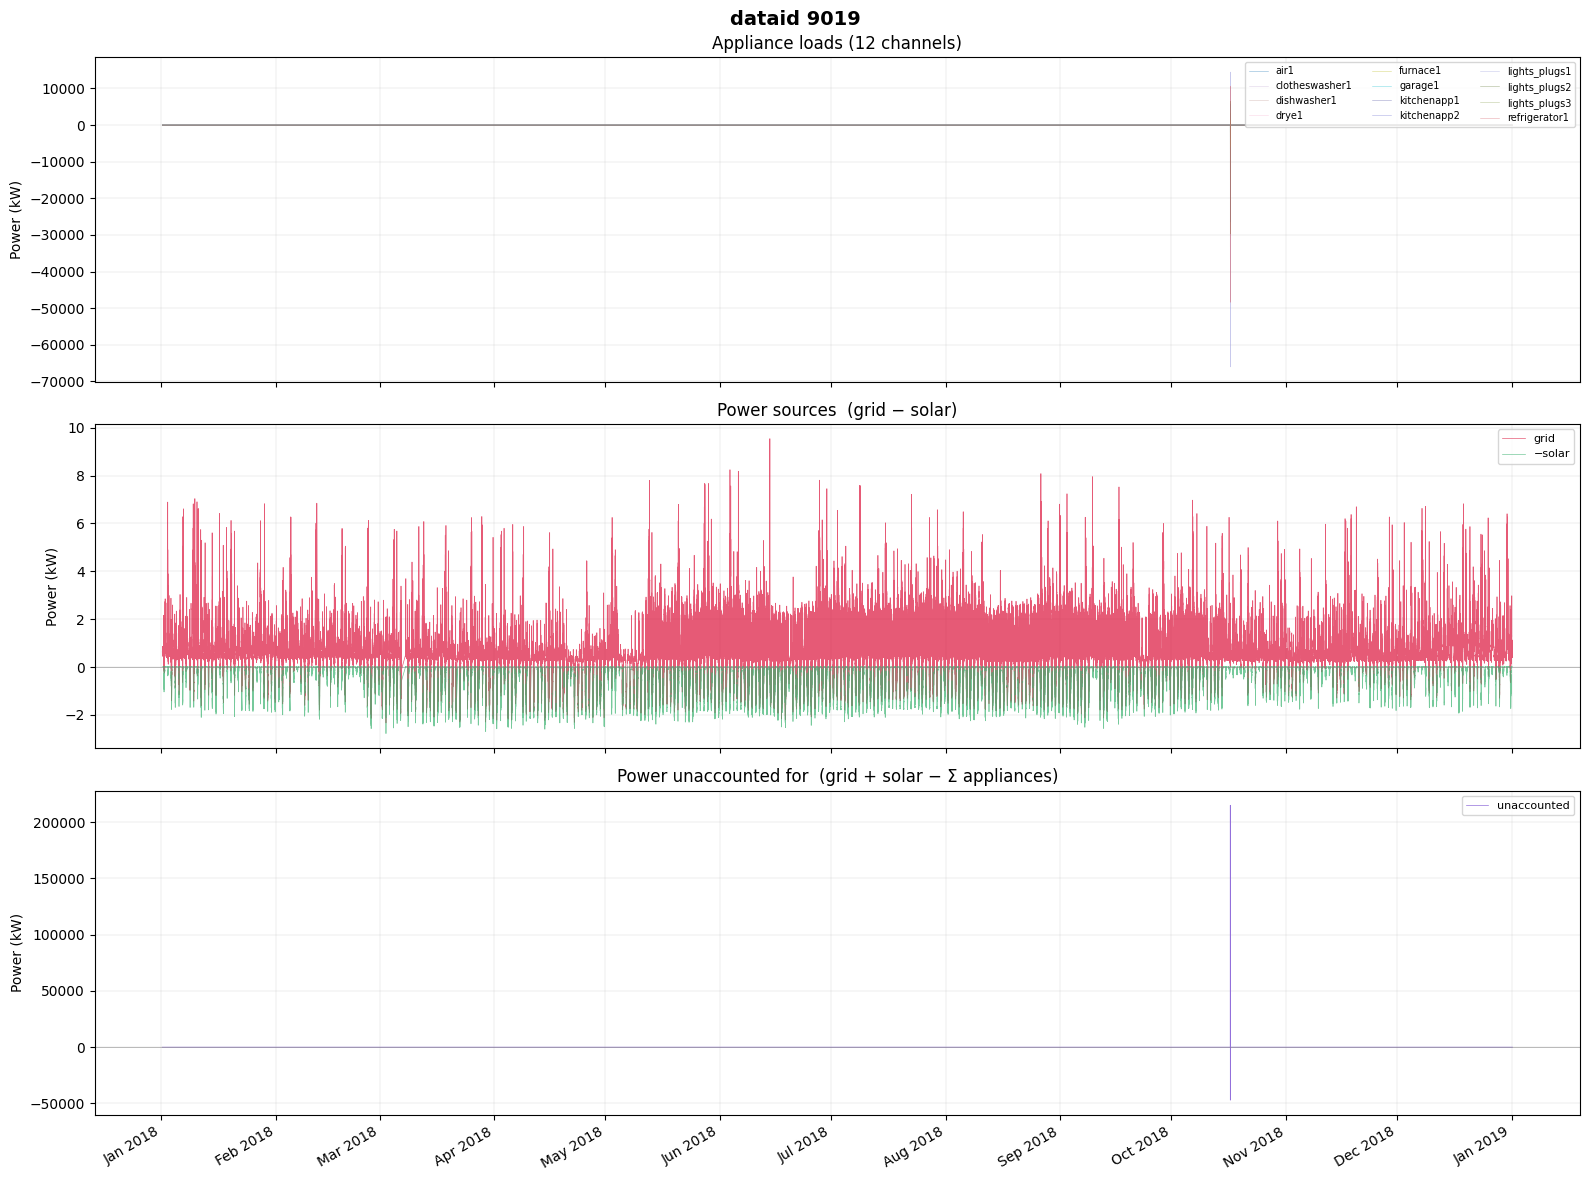

In [201]:
plot_home(austin_df, col_colors, dataid=9019)

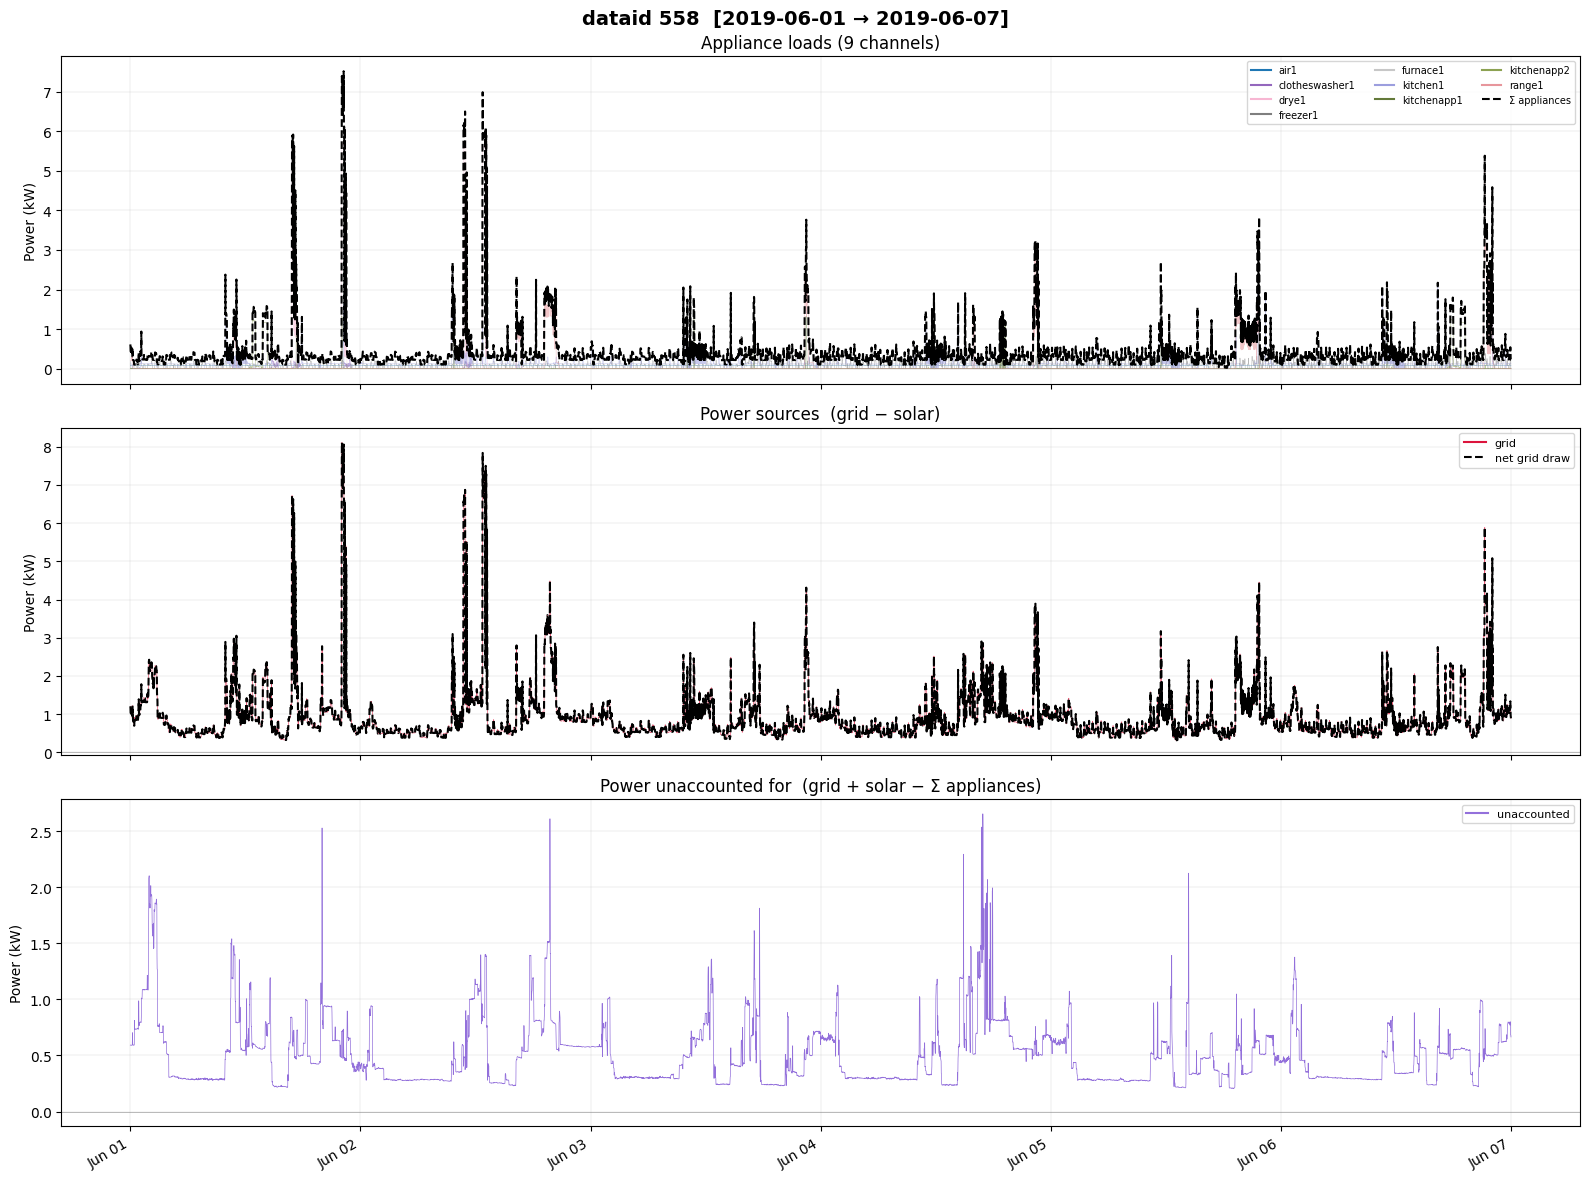

In [ ]:
import sys; sys.path.insert(0, "..")
from utils.plotting import build_color_map, plot_home

col_colors = build_color_map(new_york_df)
plot_home(new_york_df, col_colors, dataid=558, timespan=("2019-06-01", "2019-06-07"))

In [57]:
LV_COLS = ['leg1v', 'leg2v']
_META_COLS = {'dataid', 'localminute', 'leg1v', 'leg2v'}

# Columns that are non-NaN for at least one home (voltage cols handled separately)
active_feature_cols = [c for c in feature_cols if c not in _META_COLS and fill_pct[c].any()]

# Build a consistent color map: 40 distinct colors from tab20 + tab20b
_tab20  = plt.colormaps['tab20']
_tab20b = plt.colormaps['tab20b']
_palette = [_tab20(i) for i in range(20)] + [_tab20b(i) for i in range(20)]

COL_COLORS = {col: _palette[i % len(_palette)] for i, col in enumerate(active_feature_cols)}
COL_COLORS['leg1v'] = 'steelblue'
COL_COLORS['leg2v'] = 'tomato'

print(f"Color map defined for {len(active_feature_cols)} feature channels + {len(LV_COLS)} voltage channels.")

Color map defined for 46 feature channels + 2 voltage channels.


In [65]:
def plot_home(
    df,
    dataid,
    timespan=None,
    show_voltage=False,
    show_features=True,
    channels=None,
    figsize=None,
):
    """
    Plot time-series data for a single home.

    Parameters
    ----------
    df : pd.DataFrame
        Full dataset with 'dataid' and 'localminute' columns.
    dataid : int
        Home identifier to plot.
    timespan : tuple of str, optional
        (start, end) date strings, e.g. ('2019-06-01', '2019-08-01').
        If None, the full available range is shown.
    show_voltage : bool, default False
        Whether to show the leg voltage (leg1v / leg2v) subplot.
    show_features : bool, default True
        Whether to show the feature channels subplot.
    channels : list of str, optional
        Specific feature channels to plot. If None, all non-NaN channels
        for this home are plotted.
    figsize : tuple of (float, float), optional
        Figure size. Defaults to (16, 5) per subplot.
    """
    if not show_voltage and not show_features:
        raise ValueError("At least one of show_voltage or show_features must be True.")

    home = (
        df[df['dataid'] == dataid]
        .sort_values('localminute')
        .set_index('localminute')
    )

    if timespan is not None:
        start = pd.Timestamp(timespan[0]).tz_localize('UTC')
        end   = pd.Timestamp(timespan[1]).tz_localize('UTC')
        home  = home[start:end]

    n_plots = sum([show_voltage, show_features])
    fig, axes = plt.subplots(n_plots, 1, figsize=figsize or (16, 5 * n_plots),
                             sharex=True, squeeze=False)
    axes = axes.flatten()
    ax_idx = 0

    title = f'dataid {dataid}'
    if timespan is not None:
        title += f'  [{timespan[0]} → {timespan[1]}]'
    fig.suptitle(title, fontsize=14, fontweight='bold')

    if show_voltage:
        ax = axes[ax_idx]; ax_idx += 1
        for col in LV_COLS:
            ax.plot(home.index, home[col], linewidth=0.5,
                    color=COL_COLORS.get(col), label=col)
        ax.set_ylabel('Voltage (V)')
        ax.set_title('Leg voltages')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, linewidth=0.3, alpha=0.9)

    if show_features:
        ax = axes[ax_idx]; ax_idx += 1
        plot_cols = (
            channels if channels is not None
            else [c for c in active_feature_cols if home[c].notna().any()]
        )
        for col in plot_cols:
            ax.plot(home.index, home[col], linewidth=0.3, alpha=0.75,
                    color=COL_COLORS.get(col), label=col)
        ax.set_ylabel('Power (kW)')
        ax.set_title(f'Feature channels ({len(plot_cols)} shown)')
        ax.legend(loc='upper right', fontsize=7, ncol=3)
        ax.grid(True, linewidth=0.3, alpha=0.9)

    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.show()

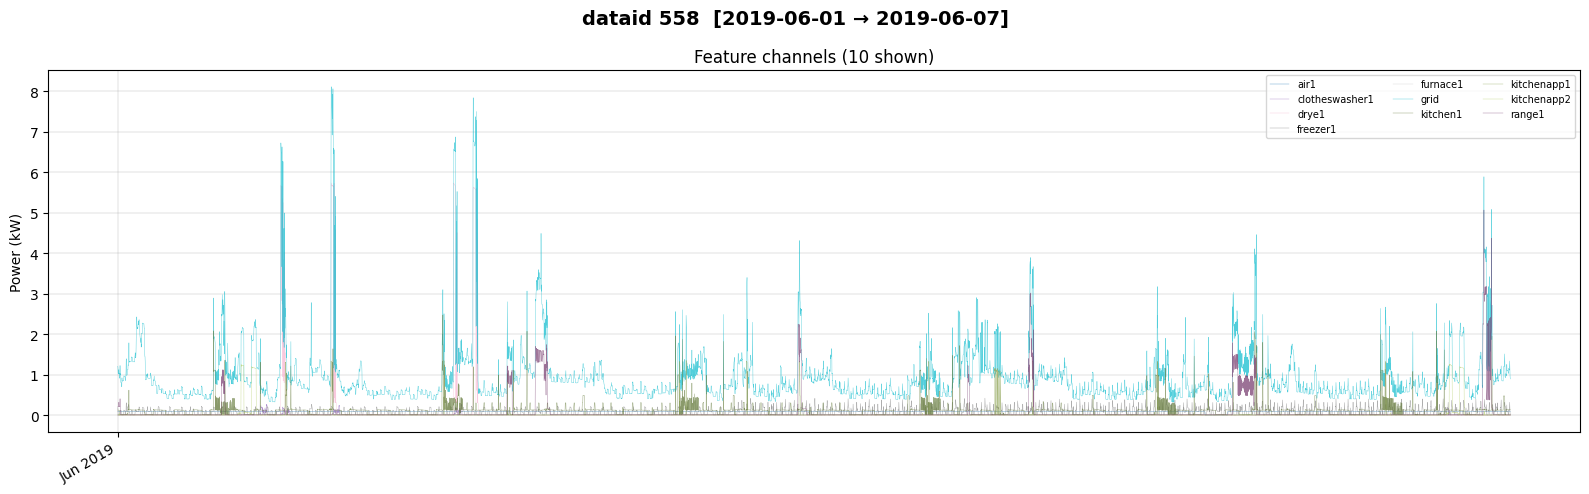

In [66]:
# Full date range, features only (default)
# plot_home(new_york_df, dataid=558)

plot_home(
    new_york_df, 
    dataid=558, # no solar
    timespan=('2019-06-01', '2019-06-07'), 
    show_voltage=False, 
    show_features=True,
)

# Specific channels only
# plot_home(new_york_df, dataid=27, channels=['solar', 'grid', 'waterheater1'])